In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats

In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

In [3]:
## performance: per seed performance
## lats_performance: avg over seed performance at the end of training
## last_performance_unnormalized: same as last_performance but without normalization
## max_performance: average over seeds (how?) max performance achieved during training (presumably)

In [11]:
ylorbr_colors = sns.color_palette("YlOrBr", n_colors=5)  # Get 5 to pick distinct ones
algo_colors = {
    "ppo": ylorbr_colors[1],   # Light orange
    "dqn": ylorbr_colors[2],   # Medium orange
    "sac": ylorbr_colors[4],   # Dark brown
}

# 1. Normalization

In [5]:
# normalization cross-algorithm per environment
data["normed_performance"] = data.groupby("env_name")["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["normed_performance_per_alg"] = data.groupby(["env_name", "algorithm"])["performance"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)
)

# on data_two we normalize per env and algorithm
data["_seed_avg"] = data.groupby(["env_name", "algorithm", "config_id"])["performance"].transform("mean")
data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False).apply(
    lambda g: (g["performance"] - g["_seed_avg"].min()) / (g["_seed_avg"].max() - g["_seed_avg"].min() + 1e-8)
)
data.drop(columns=["_seed_avg"], inplace=True)

/var/folders/5n/lj6nx7xj3mx2yb3sk947mnlc0000gn/T/ipykernel_41409/355322313.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data["normed_performance_per_alg_seedavg"] = data.groupby(["env_name", "algorithm"], group_keys=False).apply(


# 2. Training Volatility

What I wnan test is essentially, if for ALL configurations, we roughly have a relation of the form
$$h \text{ bad on }m \sim h\text{ bad on all other }m'$$

Essentially we want to further investigate "Hparams seem to rarely cause full performance degradation from one
environment to the other and are not responsible for reward curve undulations in training."

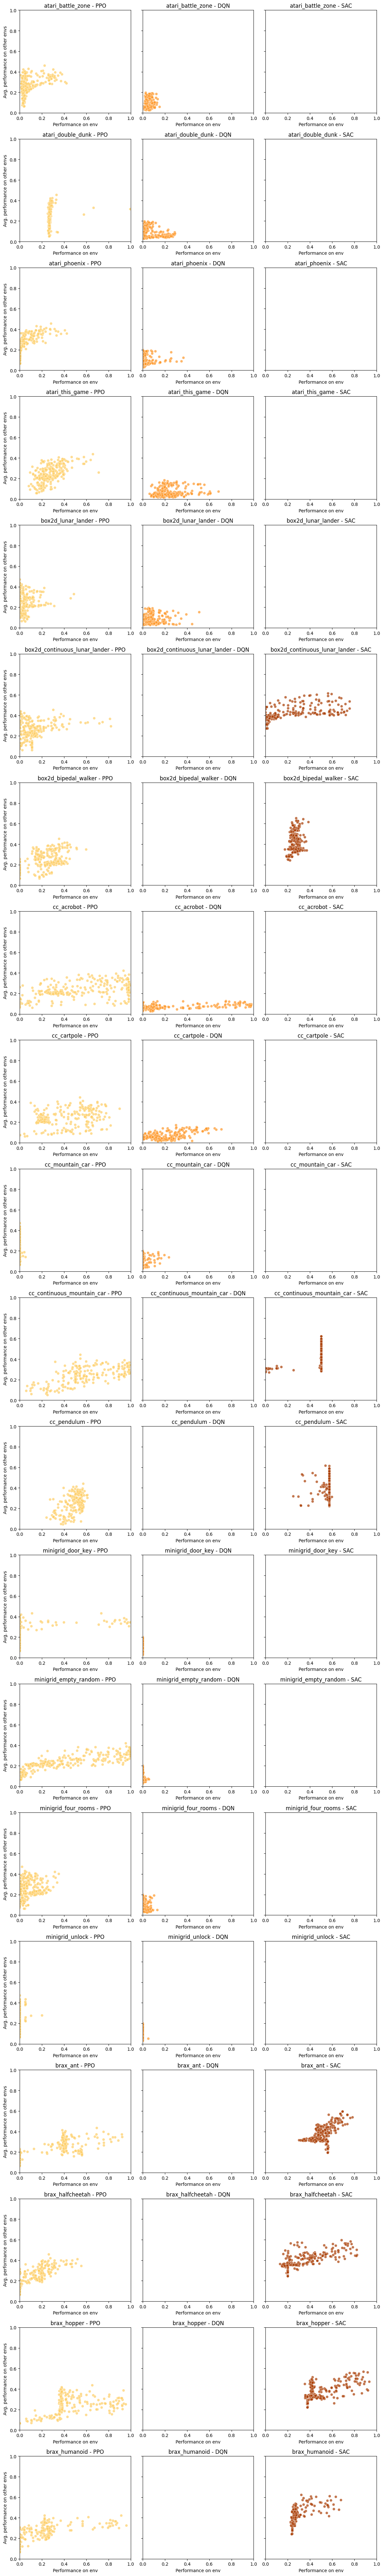

In [6]:
n_cols = 3
algos = data["algorithm"].unique()
envs = data["env_name"].unique()


fig, axes = plt.subplots(len(envs), n_cols, figsize=(12, 4*len(envs)), sharey=True)
axes = axes.reshape(len(envs), n_cols)

for m, env in enumerate(envs):

    for a, alg in enumerate(algos):

        ax = axes[m, a]
        alg_env_subset = data[(data["algorithm"] == alg) & (data["env_name"] == env)]
        alg_other_env_subset = data[(data["algorithm"] == alg) & (data["env_name"] != env)]

        alg_env_data = {
            "h_on_m": [],
            "h_on_other": []
        }

        for h in alg_env_subset["config_id"].unique():
            h_on_m = alg_env_subset[alg_env_subset["config_id"] == h]["normed_performance"].mean()
            h_on_other = (
                alg_other_env_subset[alg_other_env_subset["config_id"] == h]
                .groupby("env_name")["normed_performance"]
                .mean()  # mean per env_name
                .mean()  # mean of the env means
            )

            alg_env_data["h_on_m"].append(h_on_m)
            alg_env_data["h_on_other"].append(h_on_other)

        alg_env_data = pd.DataFrame(alg_env_data) 
        sns.scatterplot(
            data=alg_env_data,
            x="h_on_m",
            y="h_on_other",
            ax=ax,
            alpha=0.7,
            color=algo_colors.get(alg, "#333333"),
        )

        # Fix axis limits to 0-1
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        
        # Set title for each subplot
        ax.set_title(f"{env} - {alg.upper()}")
        
        # Show x-ticks for every row
        ax.tick_params(axis='x', labelbottom=True)
        
        # Set axis labels
        ax.set_xlabel("Performance on env")
        ax.set_ylabel("Avg. performance on other envs" if a == 0 else "")

plt.tight_layout()

Algorithm: PPO, number of configs: 5120
Algorithm: PPO, Correlation: 0.17
Algorithm: DQN, number of configs: 3072
Algorithm: DQN, Correlation: -0.02
Algorithm: SAC, number of configs: 2048
Algorithm: SAC, Correlation: 0.16


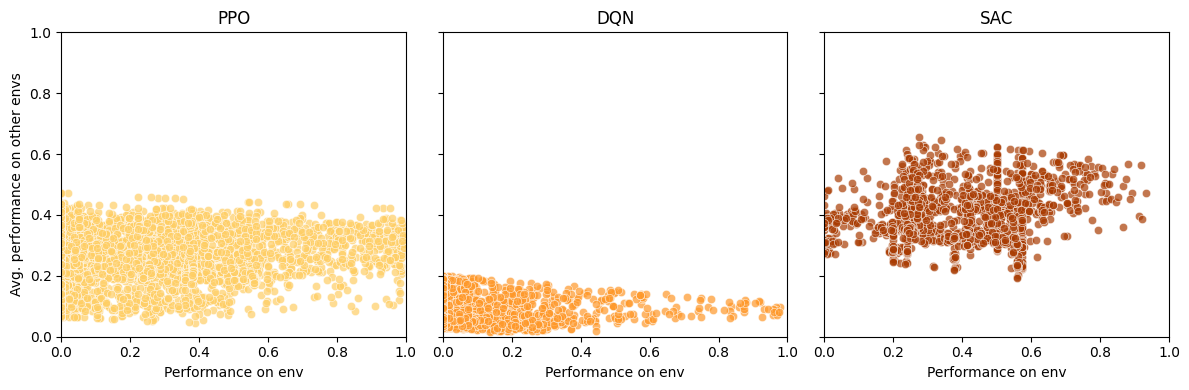

In [7]:
n_cols = 3
algos = data["algorithm"].unique()
envs = data["env_name"].unique()

# Define colors for each algorithm

fig, axes = plt.subplots(1, n_cols, figsize=(12, 4), sharey=True)
axes = axes.flatten()

for a, alg in enumerate(algos):

    alg_data = {
        "h_on_m": [],
        "h_on_other": []
    }

    for m, env in enumerate(envs):


        ax = axes[a]
        alg_env_subset = data[(data["algorithm"] == alg) & (data["env_name"] == env)]
        alg_other_env_subset = data[(data["algorithm"] == alg) & (data["env_name"] != env)]

        for h in alg_env_subset["config_id"].unique():
            h_on_m = alg_env_subset[alg_env_subset["config_id"] == h]["normed_performance"].mean()
            h_on_other = (
                alg_other_env_subset[alg_other_env_subset["config_id"] == h]
                .groupby("env_name")["normed_performance"]
                .mean()  # mean per env_name
                .mean()  # mean of the env means
            )

            alg_data["h_on_m"].append(h_on_m)
            alg_data["h_on_other"].append(h_on_other)

    alg_data = pd.DataFrame(alg_data) 
    print(f"Algorithm: {alg.upper()}, number of configs: {len(alg_data)}")
    print(f"Algorithm: {alg.upper()}, Correlation: {stats.pearsonr(alg_data['h_on_m'], alg_data['h_on_other'])[0]:.2f}")
    sns.scatterplot(
        data=alg_data,
        x="h_on_m",
        y="h_on_other",
        ax=ax,
        alpha=0.7,
        color=algo_colors.get(alg, "#333333"),
    )

    # Fix axis limits to 0-1
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # Set title for each subplot
    ax.set_title(f"{alg.upper()}")
    
    # Show x-ticks for every row
    ax.tick_params(axis='x', labelbottom=True)
    
    # Set axis labels
    ax.set_xlabel("Performance on env")
    ax.set_ylabel("Avg. performance on other envs" if a == 0 else "")

plt.tight_layout()

## Repeat, but instead of tracking on ALL others, track only on others on domain

In [8]:
data["domain"] = data["env_name"].apply(lambda x: x.split("_")[0])

# remove all data that has cc_mountan_car as env_name
data = data[data["env_name"] != "cc_mountain_car"]



Algorithm: PPO, number of configs: 4864
Algorithm: PPO, Correlation: 0.47
Algorithm: DQN, number of configs: 2816
Algorithm: DQN, Correlation: nan
Algorithm: SAC, number of configs: 2048
Algorithm: SAC, Correlation: 0.43


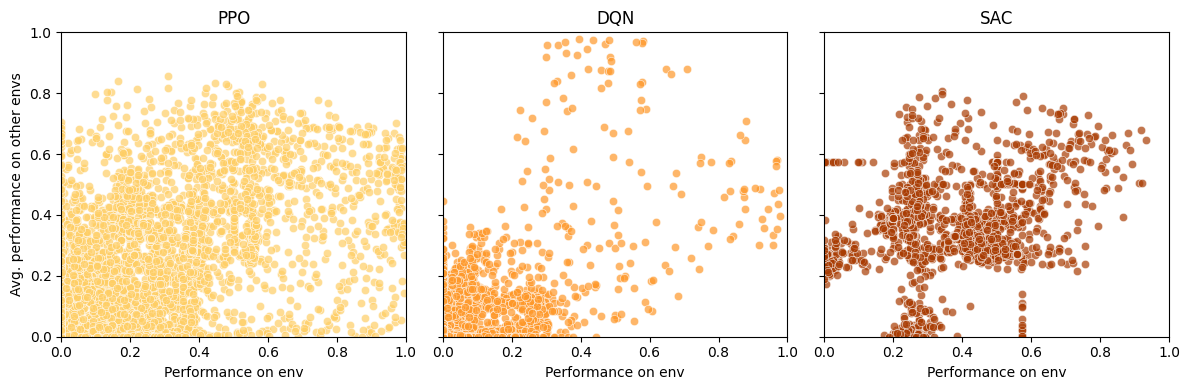

In [12]:
n_cols = 3
algos = data["algorithm"].unique()
envs = data["env_name"].unique()


fig, axes = plt.subplots(1, n_cols, figsize=(12, 4), sharey=True)
axes = axes.flatten()

for a, alg in enumerate(algos):

    alg_data = {
        "h_on_m": [],
        "h_on_other": []
    }

    for m, env in enumerate(envs):

        domain = env.split("_")[0]
        ax = axes[a]
        alg_env_subset = data[(data["algorithm"] == alg) & (data["env_name"] == env)]
        alg_other_env_subset = data[(data["algorithm"] == alg) & (data["env_name"] != env) & (data["domain"] == domain)]

        for h in alg_env_subset["config_id"].unique():
            h_on_m = alg_env_subset[alg_env_subset["config_id"] == h]["normed_performance"].mean()
            h_on_other = (
                alg_other_env_subset[alg_other_env_subset["config_id"] == h]
                .groupby("env_name")["normed_performance"]
                .mean()  # mean per env_name
                .mean()  # mean of the env means
            )

            alg_data["h_on_m"].append(h_on_m)
            alg_data["h_on_other"].append(h_on_other)

    alg_data = pd.DataFrame(alg_data) 
    print(f"Algorithm: {alg.upper()}, number of configs: {len(alg_data)}")
    print(f"Algorithm: {alg.upper()}, Correlation: {stats.pearsonr(alg_data['h_on_m'], alg_data['h_on_other'])[0]:.2f}")
    sns.scatterplot(
        data=alg_data,
        x="h_on_m",
        y="h_on_other",
        ax=ax,
        alpha=0.7,
        color=algo_colors.get(alg, "#333333"),
    )

    # Fix axis limits to 0-1
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # Set title for each subplot
    ax.set_title(f"{alg.upper()}")
    
    # Show x-ticks for every row
    ax.tick_params(axis='x', labelbottom=True)
    
    # Set axis labels
    ax.set_xlabel("Performance on env")
    ax.set_ylabel("Avg. performance on other envs" if a == 0 else "")

plt.tight_layout()